# Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Import Dataset

In [2]:
train_df = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
test_df  = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


# EDA

In [3]:
train_df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [4]:
train_df.head(20)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [5]:
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
train_df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

<Axes: xlabel='CryoSleep', ylabel='HomePlanet'>

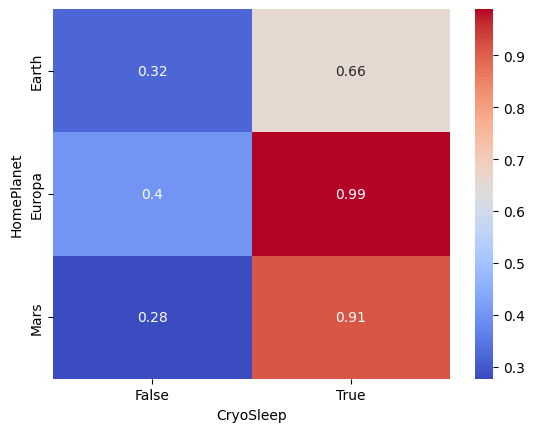

In [7]:
pivot = train_df.pivot_table(index = "HomePlanet" , columns = "CryoSleep" , values = "Transported" , aggfunc  = "mean")
sns.heatmap (pivot , annot = True , cmap = "coolwarm")

In [8]:
train_df.drop("Name" , inplace = True  ,axis = 1)
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


<Axes: xlabel='VIP', ylabel='Destination'>

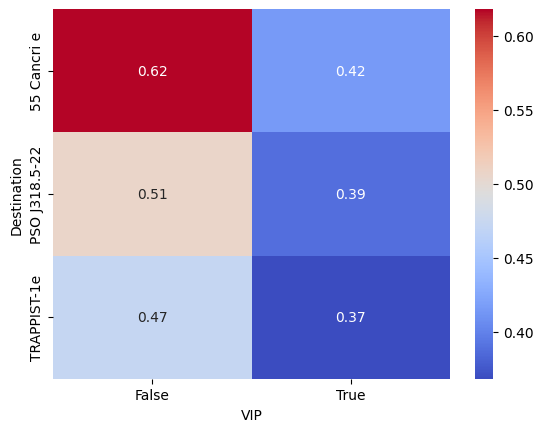

In [9]:
pivot2 = train_df.pivot_table(index = "Destination" , columns = "VIP" , values = "Transported" , aggfunc  = "mean")
sns.heatmap(pivot2 , annot = True , cmap = "coolwarm")

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1


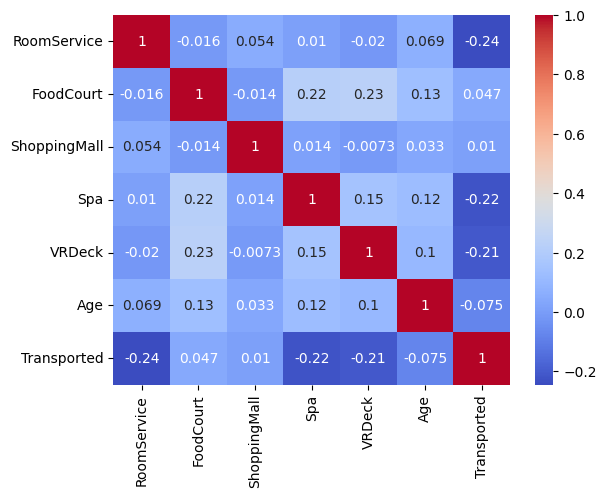

In [10]:
train_df['Transported'] = train_df['Transported'].astype(int)
num_features = ["RoomService" , "FoodCourt","ShoppingMall" , "Spa" , "VRDeck", "Age" ,"Transported"]
corr = train_df[num_features].corr()
sns.heatmap(corr , annot=True ,cmap= "coolwarm" )
train_df.head()

# Feature Extraction

* PassengerId is divided into 3 features

* Cabin is divided into 3 features

* Total spending and a binary spending indicator will be added as features.

In [11]:
spend_features = ["RoomService" , "FoodCourt","ShoppingMall" , "Spa" , "VRDeck" ]
train_df["TotalSpending"] = train_df[spend_features].sum(axis=1)
train_df["HasSpent"] = (train_df["TotalSpending"] > 0).astype(int)

train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,HasSpent
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,736.0,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,10383.0,1
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,5176.0,1
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,1091.0,1


In [12]:
train_df[["GroupId" , "GroupNum"]] = train_df["PassengerId"].str.split("_" , expand = True)
train_df["GroupSize"] = train_df.groupby("GroupId")["GroupId"].transform("count")
train_df.drop("PassengerId" ,inplace = True , axis = 1)

print(train_df["GroupSize"].value_counts())
train_df.tail()

GroupSize
1    4805
2    1682
3    1020
4     412
5     265
7     231
6     174
8     104
Name: count, dtype: int64


,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,HasSpent,GroupId,GroupNum,GroupSize
8688,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,0,8536.0,1,9276,01,1
8689,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,9278,01,1
8690,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,1,1873.0,1,9279,01,1
8691,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,0,4637.0,1,9280,01,2
8692,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,1,4826.0,1,9280,02,2


In [13]:
train_df[["CabinDeck" , "CabinNum", "CabinSide"]] = train_df["Cabin"].str.split("/" , expand = True)
train_df.drop("Cabin" , inplace = True , axis = 1)
train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,HasSpent,GroupId,GroupNum,GroupSize,CabinDeck,CabinNum,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0001,01,1,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,736.0,1,0002,01,1,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,10383.0,1,0003,01,2,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,5176.0,1,0003,02,2,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,1091.0,1,0004,01,1,F,1,S


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HomePlanet     8492 non-null   object 
 1   CryoSleep      8476 non-null   object 
 2   Destination    8511 non-null   object 
 3   Age            8514 non-null   float64
 4   VIP            8490 non-null   object 
 5   RoomService    8512 non-null   float64
 6   FoodCourt      8510 non-null   float64
 7   ShoppingMall   8485 non-null   float64
 8   Spa            8510 non-null   float64
 9   VRDeck         8505 non-null   float64
 10  Transported    8693 non-null   int64  
 11  TotalSpending  8693 non-null   float64
 12  HasSpent       8693 non-null   int64  
 13  GroupId        8693 non-null   object 
 14  GroupNum       8693 non-null   object 
 15  GroupSize      8693 non-null   int64  
 16  CabinDeck      8494 non-null   object 
 17  CabinNum       8494 non-null   object 
 18  CabinSid

# Outlier

Text(0.5, 1.0, 'Yaş Harcama İlişkisi')

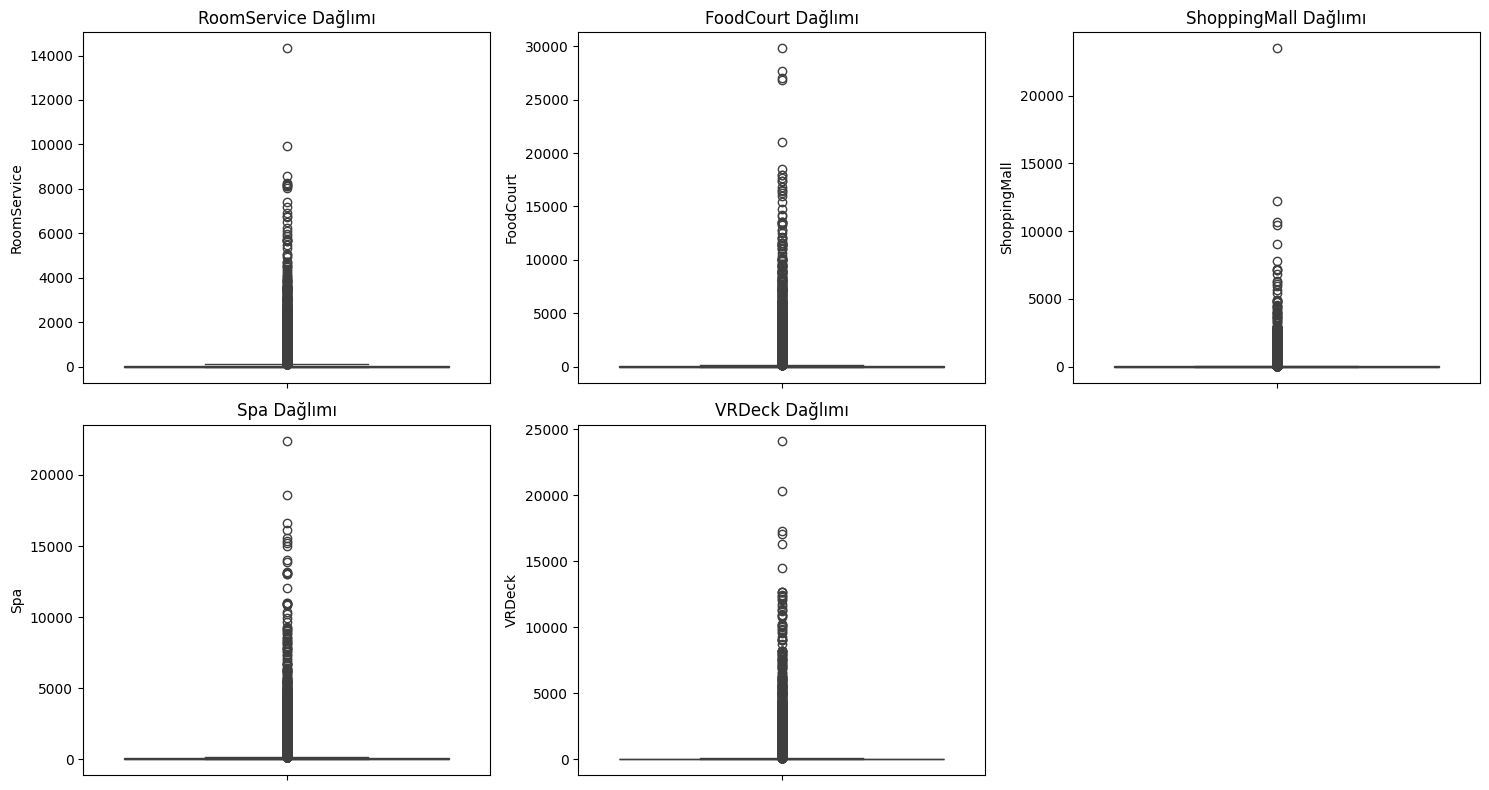

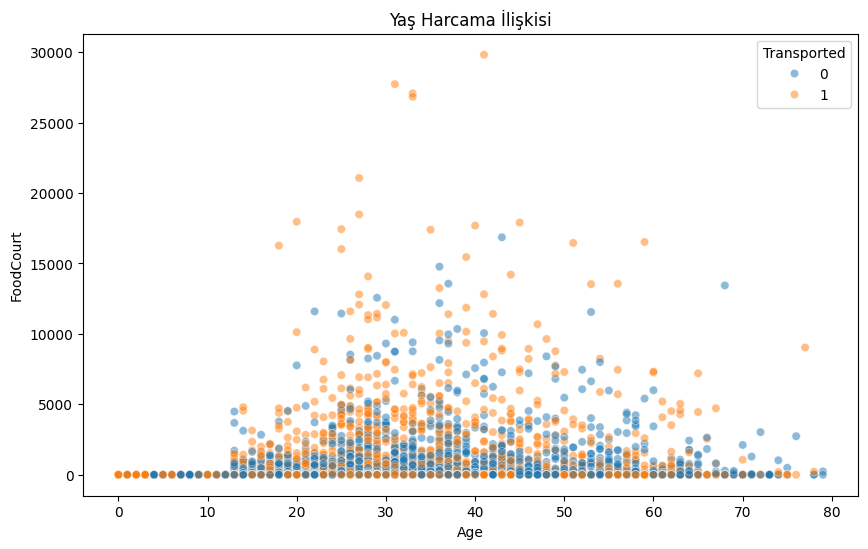

In [15]:
plt.figure(figsize=(15,8))
for i , col in enumerate(spend_features):
    plt.subplot(2,3,i+1)
    sns.boxplot(y= train_df[col])
    plt.title(f"{col} Dağlımı")

plt.tight_layout()

plt.figure(figsize=(10,6))
sns.scatterplot(data = train_df , x="Age" , y = "FoodCourt" ,hue = "Transported" , alpha = 0.5)
plt.title("Yaş Harcama İlişkisi")

## IQR

In [16]:
def iqr_analiz(carpan):
    print(f"---------------------------------------- {carpan} ÇARPANIYLA ANALİZ ----------------------------------------" )
    for col in spend_features:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1

        ust_sinir = Q3 + (carpan * IQR)
        alt_sinir = Q1 - (carpan * IQR)

        outlier_sayisi = len(train_df[(train_df[col] > ust_sinir ) |(train_df[col] < alt_sinir) ])
        
        print(f"-----{col} Analizi-----")
        print(f"Üst Sınır: {ust_sinir}")
        print(f"Alt Sınır: {alt_sinir}")
        print(f"Outlier Sayısı: {outlier_sayisi}")
        print(f"Değerler Toplamı: {train_df[col].value_counts()}")
        print(f"Unique Değerler: {train_df[col].nunique()}")
iqr_analiz(1.5)
iqr_analiz(30)
#Outliers will not be filtered out

---------------------------------------- 1.5 ÇARPANIYLA ANALİZ ----------------------------------------
-----RoomService Analizi-----
Üst Sınır: 117.5
Alt Sınır: -70.5
Outlier Sayısı: 1861
Değerler Toplamı: RoomService
0.0       5577
1.0        117
2.0         79
3.0         61
4.0         47
          ... 
6899.0       1
1954.0       1
3146.0       1
1297.0       1
2555.0       1
Name: count, Length: 1273, dtype: int64
Unique Değerler: 1273
-----FoodCourt Analizi-----
Üst Sınır: 190.0
Alt Sınır: -114.0
Outlier Sayısı: 1823
Değerler Toplamı: FoodCourt
0.0       5456
1.0        116
2.0         75
4.0         53
3.0         53
          ... 
2053.0       1
432.0        1
5151.0       1
3456.0       1
1652.0       1
Name: count, Length: 1507, dtype: int64
Unique Değerler: 1507
-----ShoppingMall Analizi-----
Üst Sınır: 67.5
Alt Sınır: -40.5
Outlier Sayısı: 1829
Değerler Toplamı: ShoppingMall
0.0        5587
1.0         153
2.0          80
3.0          59
4.0          45
           ... 
563

# Missing Values

In [17]:
train_df.isnull().sum().sort_values(ascending=False)

CryoSleep        217
ShoppingMall     208
VIP              203
HomePlanet       201
CabinDeck        199
CabinSide        199
CabinNum         199
VRDeck           188
Spa              183
FoodCourt        183
Destination      182
RoomService      181
Age              179
Transported        0
TotalSpending      0
GroupNum           0
GroupId            0
HasSpent           0
GroupSize          0
dtype: int64

In [18]:
conflicted_passenger = train_df[(train_df["CryoSleep"] == True) & (train_df["HasSpent"] == 1)]
print (conflicted_passenger)

Empty DataFrame
Columns: [HomePlanet, CryoSleep, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Transported, TotalSpending, HasSpent, GroupId, GroupNum, GroupSize, CabinDeck, CabinNum, CabinSide]
Index: []


In [19]:
train_df.isnull().sum().sort_values(ascending = False)
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())
train_df.isnull().sum().sort_values(ascending = False)

CryoSleep        217
ShoppingMall     208
VIP              203
HomePlanet       201
CabinDeck        199
CabinSide        199
CabinNum         199
VRDeck           188
Spa              183
FoodCourt        183
Destination      182
RoomService      181
Age                0
Transported        0
TotalSpending      0
GroupNum           0
GroupId            0
HasSpent           0
GroupSize          0
dtype: int64

In [20]:
train_df["Destination"].value_counts()
train_df["Destination"] = train_df["Destination"].fillna(train_df["Destination"].mode()[0])
train_df.isnull().sum().sort_values()

Age                0
Destination        0
GroupSize          0
GroupNum           0
HasSpent           0
GroupId            0
Transported        0
TotalSpending      0
RoomService      181
FoodCourt        183
Spa              183
VRDeck           188
CabinNum         199
CabinSide        199
CabinDeck        199
HomePlanet       201
VIP              203
ShoppingMall     208
CryoSleep        217
dtype: int64

In [21]:
empty = train_df[spend_features].isnull().all(axis = 1)
empty.sum()

np.int64(0)

In [22]:
train_df.loc[train_df["HasSpent"] == 0 , spend_features] = train_df.loc[train_df["HasSpent"] == 0 , spend_features].fillna(0)
train_df.isnull().sum().sort_values()

Age                0
Destination        0
GroupSize          0
GroupNum           0
HasSpent           0
GroupId            0
Transported        0
TotalSpending      0
ShoppingMall     100
FoodCourt        102
VRDeck           102
RoomService      103
Spa              112
CabinSide        199
CabinNum         199
CabinDeck        199
HomePlanet       201
VIP              203
CryoSleep        217
dtype: int64

In [23]:
imputer = KNNImputer(n_neighbors = 5)
train_df[spend_features] = imputer.fit_transform(train_df[spend_features])
train_df.isnull().sum().sort_values(ascending = False )

CryoSleep        217
VIP              203
HomePlanet       201
CabinSide        199
CabinDeck        199
CabinNum         199
Destination        0
ShoppingMall       0
Age                0
RoomService        0
FoodCourt          0
Transported        0
VRDeck             0
Spa                0
TotalSpending      0
GroupNum           0
GroupId            0
HasSpent           0
GroupSize          0
dtype: int64

In [24]:
train_df["HomePlanet"].value_counts()
train_df["HomePlanet"] = train_df.groupby("GroupId")["HomePlanet"].transform(lambda x : x.fillna(method = "ffill").fillna(method = "bfill"))
train_df["HomePlanet"] = train_df["HomePlanet"].fillna(train_df["HomePlanet"].mode()[0])
train_df.isnull().sum().sort_values()

/tmp/ipykernel_17/3078761183.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df["HomePlanet"] = train_df.groupby("GroupId")["HomePlanet"].transform(lambda x : x.fillna(method = "ffill").fillna(method = "bfill"))
/tmp/ipykernel_17/3078761183.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df["HomePlanet"] = train_df.groupby("GroupId")["HomePlanet"].transform(lambda x : x.fillna(method = "ffill").fillna(method = "bfill"))


HomePlanet         0
Destination        0
Age                0
RoomService        0
ShoppingMall       0
FoodCourt          0
VRDeck             0
Spa                0
HasSpent           0
GroupId            0
Transported        0
TotalSpending      0
GroupNum           0
GroupSize          0
CabinNum         199
CabinDeck        199
CabinSide        199
VIP              203
CryoSleep        217
dtype: int64

In [25]:
train_df["CabinNum"] = pd.to_numeric(train_df["CabinNum"] , errors = "coerce")

columnss = ["CabinNum" ,"CabinDeck","CabinSide"]

for col in columnss:
    train_df[col] = train_df.groupby("GroupId")[col].transform(lambda x : x.ffill().bfill())

print(train_df.isnull().sum().sort_values())

train_df["CabinDeck"] = train_df["CabinDeck"].fillna("Unk")
train_df["CabinSide"] = train_df["CabinSide"].fillna("Unk")

train_df["CabinNum"] = imputer.fit_transform(train_df[["CabinNum"]])

print(train_df.isnull().sum().sort_values())

/tmp/ipykernel_17/3548482218.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df.groupby("GroupId")[col].transform(lambda x : x.ffill().bfill())
/tmp/ipykernel_17/3548482218.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df.groupby("GroupId")[col].transform(lambda x : x.ffill().bfill())


HomePlanet         0
Destination        0
Age                0
RoomService        0
ShoppingMall       0
FoodCourt          0
VRDeck             0
Spa                0
HasSpent           0
GroupId            0
Transported        0
TotalSpending      0
GroupNum           0
GroupSize          0
CabinNum          99
CabinDeck         99
CabinSide         99
VIP              203
CryoSleep        217
dtype: int64
HomePlanet         0
Destination        0
Age                0
RoomService        0
ShoppingMall       0
FoodCourt          0
VRDeck             0
Spa                0
HasSpent           0
GroupId            0
Transported        0
TotalSpending      0
GroupNum           0
GroupSize          0
CabinNum           0
CabinDeck          0
CabinSide          0
VIP              203
CryoSleep        217
dtype: int64


In [26]:
train_df.loc[train_df["VIP"] == False , "VIP"] = 0
train_df.loc[train_df["VIP"] == True , "VIP"] = 1

train_df["VIP"] = imputer.fit_transform(train_df[["VIP"]])

print(train_df.isnull().sum().sort_values())
train_df.head(20)

HomePlanet         0
Destination        0
Age                0
VIP                0
FoodCourt          0
RoomService        0
ShoppingMall       0
Spa                0
HasSpent           0
VRDeck             0
Transported        0
TotalSpending      0
GroupNum           0
GroupId            0
GroupSize          0
CabinDeck          0
CabinSide          0
CabinNum           0
CryoSleep        217
dtype: int64


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,HasSpent,GroupId,GroupNum,GroupSize,CabinDeck,CabinNum,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0001,01,1,B,0.000000,P
1,Earth,False,TRAPPIST-1e,24.0,0.0,109.0,9.0,25.0,549.0,44.0,1,736.0,1,0002,01,1,F,0.000000,S
2,Europa,False,TRAPPIST-1e,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,0,10383.0,1,0003,01,2,A,0.000000,S
3,Europa,False,TRAPPIST-1e,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,0,5176.0,1,0003,02,2,A,0.000000,S
4,Earth,False,TRAPPIST-1e,16.0,0.0,303.0,70.0,151.0,565.0,2.0,1,1091.0,1,0004,01,1,F,1.000000,S
5,Earth,False,PSO J318.5-22,44.0,0.0,0.0,483.0,0.0,291.0,0.0,1,774.0,1,0005,01,1,F,0.000000,P
6,Earth,False,TRAPPIST-1e,26.0,0.0,42.0,1539.0,3.0,0.0,0.0,1,1584.0,1,0006,01,2,F,2.000000,S
7,Earth,True,TRAPPIST-1e,28.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0,0006,02,2,G,0.000000,S
8,Earth,False,TRAPPIST-1e,35.0,0.0,0.0,785.0,17.0,216.0,0.0,1,1018.0,1,0007,01,1,F,3.000000,S
9,Europa,True,55 Cancri e,14.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0,0008,01,3,B,1.000000,P


In [27]:
train_df.loc[train_df["CryoSleep"] == False , "CryoSleep"] = 0
train_df.loc[train_df["CryoSleep"] == True , "CryoSleep"] = 1

train_df.loc [(train_df["CryoSleep"].isnull()) & (train_df["TotalSpending"] > 0 ) , "CryoSleep"] = 0

print("-------------------- Method1 --------------------")
print(train_df["CryoSleep"].isnull().sum())

train_df["CryoSleep"] = train_df.groupby("GroupId")["CryoSleep"].transform(lambda x: x.ffill().bfill())

print("-------------------- Method2 --------------------")
print(train_df["CryoSleep"].isnull().sum())

train_df["CryoSleep"] = imputer.fit_transform(train_df[["CryoSleep"]])

print("-------------------- Method3 --------------------")
print(train_df["CryoSleep"].isnull().sum())


print("-------------------- Result --------------------")
print(train_df.isnull().sum().sort_values())

-------------------- Method1 --------------------
98


/tmp/ipykernel_17/390124302.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df["CryoSleep"] = train_df.groupby("GroupId")["CryoSleep"].transform(lambda x: x.ffill().bfill())


-------------------- Method2 --------------------
37
-------------------- Method3 --------------------
0
-------------------- Result --------------------
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Transported      0
TotalSpending    0
HasSpent         0
GroupId          0
GroupNum         0
GroupSize        0
CabinDeck        0
CabinNum         0
CabinSide        0
dtype: int64


# Train Test Split